# Rossmann Store Sales: Drivers of Daily Sales Across 1,115 Stores

Real daily sales data for 1,115 Rossmann drugstores across Germany, Jan 2013 - Jul 2015 - from the Rossmann Store Sales Kaggle competition, not synthetic data.

**Goal:** understand what actually drives daily sales at store level - day of week, promotions, store type, and competition - before any forecasting model gets built on top of it (a natural follow-up, left for later).

Dataset link: https://www.kaggle.com/c/rossmann-store-sales

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.facecolor'] = 'white'
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## 1. Loading and joining

Daily sales (`train.csv`) joined with store metadata (`store.csv`: type, assortment, competition, promo history).

In [2]:
DATA_DIR = r'D:\files\Sales Datasets\Dataset3'

train = pd.read_csv(f'{DATA_DIR}\\train.csv', low_memory=False)
store = pd.read_csv(f'{DATA_DIR}\\store.csv')
train['Date'] = pd.to_datetime(train['Date'])
df = train.merge(store, on='Store', how='left')

print(f'{len(train):,} daily records | {store["Store"].nunique():,} stores')
print(f"Date range: {train['Date'].min().date()} to {train['Date'].max().date()}")
df.head()

1,017,209 daily records | 1,115 stores
Date range: 2013-01-01 to 2015-07-31


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,"1,270.00",9.00,"2,008.00",0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.00,11.00,"2,007.00",1,13.00,"2,010.00","Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,"14,130.00",12.00,"2,006.00",1,14.00,"2,011.00","Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.00,9.00,"2,009.00",0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,"29,910.00",4.00,"2,015.00",0,NaN,NaN,NaN


## 2. Data quality

`Open` is a genuine flag (closed days correctly show £0 sales, no contradictions), so this checks for missing store metadata and any open-but-zero-sales anomalies before doing anything else.

In [3]:
print('Missing values in store metadata:')
print(store.isnull().sum()[store.isnull().sum() > 0])
print()

closed_with_sales = ((df['Open'] == 0) & (df['Sales'] != 0)).sum()
open_zero_sales = ((df['Open'] == 1) & (df['Sales'] == 0)).sum()
print(f'Closed days with nonzero sales (should be 0): {closed_with_sales}')
print(f'Open days with zero sales: {open_zero_sales} ({open_zero_sales / (df["Open"]==1).sum():.2%} of open days)')

# CompetitionOpenSince* and Promo2Since* are missing exactly where there's no
# competition/no ongoing Promo2 campaign to date - not broken data, just "not
# applicable". CompetitionDistance's 3 missing rows are dropped from distance
# analysis; everything else uses the full open-day dataset.
sales_open = df[df['Open'] == 1].copy()
print(f'\nOpen-day records used for sales analysis: {len(sales_open):,}')

Missing values in store metadata:
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

Closed days with nonzero sales (should be 0): 0
Open days with zero sales: 54 (0.01% of open days)

Open-day records used for sales analysis: 844,392


## 3. Sales over time

Total monthly sales across all stores, to check for seasonality before anything else - a December spike would be the obvious expectation for a retailer.

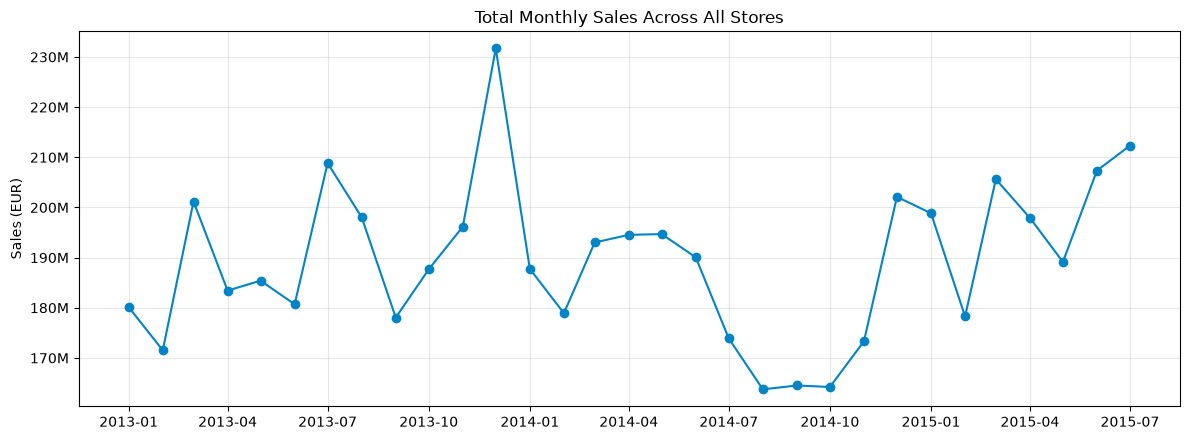

December average: 216,915,576 vs overall monthly average: 189,457,439 (+14.5%)


In [4]:
monthly = sales_open.set_index('Date').resample('MS')['Sales'].sum()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(monthly.index, monthly.values, marker='o', color='#0284c7', linewidth=1.5)
ax.set_title('Total Monthly Sales Across All Stores')
ax.set_ylabel('Sales (EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

dec_avg = monthly[monthly.index.month == 12].mean()
print(f'December average: {dec_avg:,.0f} vs overall monthly average: {monthly.mean():,.0f} '
      f'({dec_avg / monthly.mean() - 1:+.1%})')

## 4. Day-of-week pattern

Average sales per open store-day, by day of week. Worth a caveat up front: German drugstores are overwhelmingly closed on Sundays, so the Sunday figure below is based on a tiny fraction of the store-days the other six days have - it isn't a reliable "Sundays sell best" signal, just a reflection of which stores choose to open on the rare Sundays they do.

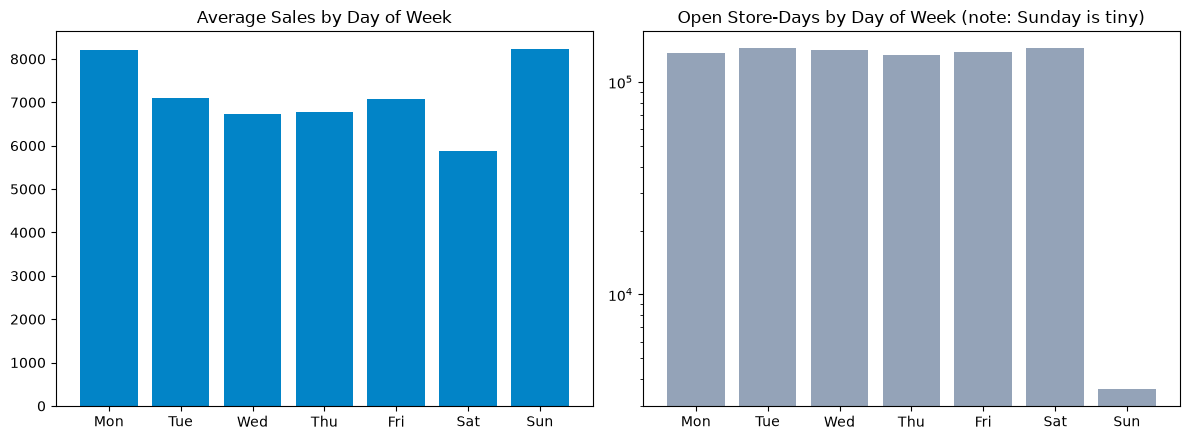

Sunday open store-days: 3,593 vs weekday average: 140,648


In [5]:
dow_labels = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
dow_sales = sales_open.groupby('DayOfWeek')['Sales'].mean()
dow_counts = sales_open.groupby('DayOfWeek').size()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar([dow_labels[d] for d in dow_sales.index], dow_sales.values, color='#0284c7')
axes[0].set_title('Average Sales by Day of Week')
axes[1].bar([dow_labels[d] for d in dow_counts.index], dow_counts.values, color='#94a3b8')
axes[1].set_title('Open Store-Days by Day of Week (note: Sunday is tiny)')
axes[1].set_yscale('log')
plt.tight_layout()
plt.show()

print(f"Sunday open store-days: {dow_counts[7]:,} vs weekday average: {dow_counts[1:6].mean():,.0f}")

## 5. Store type and assortment

`StoreType` and `Assortment` are anonymised categories (a/b/c/d), but the sales differences between them are real and worth knowing even without the underlying labels.

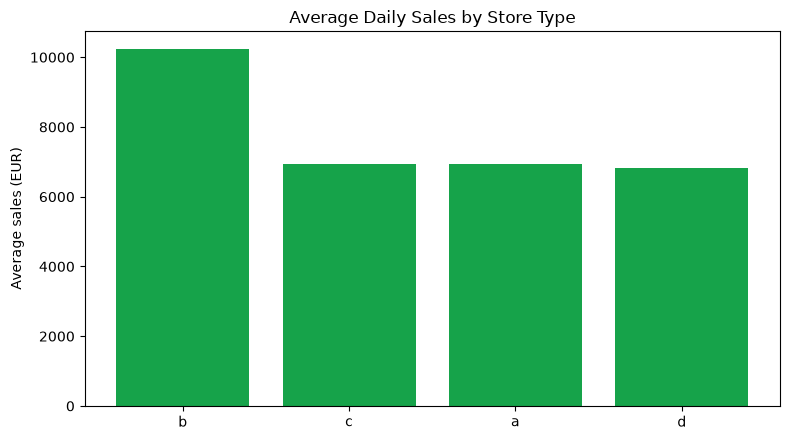

               mean   count
StoreType                  
b         10,231.41   15563
c          6,932.51  112978
a          6,925.17  457077
d          6,822.14  258774

Type 'b' stores average 50% more than the lowest-performing type, but represent only 1.8% of store-days - a small, distinct group.


In [6]:
type_sales = sales_open.groupby('StoreType')['Sales'].agg(['mean', 'count']).sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(type_sales.index, type_sales['mean'], color='#16a34a')
ax.set_title('Average Daily Sales by Store Type')
ax.set_ylabel('Average sales (EUR)')
plt.tight_layout()
plt.show()

print(type_sales)
print(f"\nType 'b' stores average {type_sales['mean'].iloc[0] / type_sales['mean'].iloc[-1] - 1:.0%} "
      f"more than the lowest-performing type, but represent only "
      f"{type_sales['count'].iloc[0] / type_sales['count'].sum():.1%} of store-days - a small, distinct group.")

## 6. Does running a promo actually move sales?

`Promo` marks whether a store was running a promotion that day - a direct,          testable question rather than an assumption.

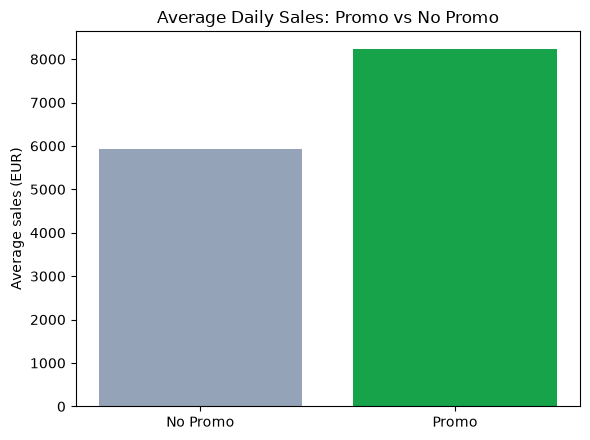

Promo days average 8,228 vs 5,929 without - a +38.8% uplift


In [7]:
promo_sales = sales_open.groupby('Promo')['Sales'].mean()
uplift = promo_sales[1] / promo_sales[0] - 1

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(['No Promo', 'Promo'], promo_sales.values, color=['#94a3b8', '#16a34a'])
ax.set_title('Average Daily Sales: Promo vs No Promo')
ax.set_ylabel('Average sales (EUR)')
plt.tight_layout()
plt.show()

print(f'Promo days average {promo_sales[1]:,.0f} vs {promo_sales[0]:,.0f} without - a {uplift:+.1%} uplift')

## 7. Does nearby competition matter?

`CompetitionDistance` is the distance in metres to the nearest competitor. The honest answer here is a useful one, even though it isn't dramatic.

In [8]:
comp_corr = sales_open[['Sales', 'CompetitionDistance']].corr().iloc[0, 1]
print(f'Correlation between daily sales and distance to nearest competitor: {comp_corr:.3f}')
print('Essentially no linear relationship - competition proximity alone does not '
      'predict a store\'s sales level in this data. Store type and promo activity '
      'matter far more than how close the nearest competitor is.')

Correlation between daily sales and distance to nearest competitor: -0.036
Essentially no linear relationship - competition proximity alone does not predict a store's sales level in this data. Store type and promo activity matter far more than how close the nearest competitor is.


## 8. Store-level variability

Every store-type/promo pattern above is an average - actual store performance varies a lot underneath it.

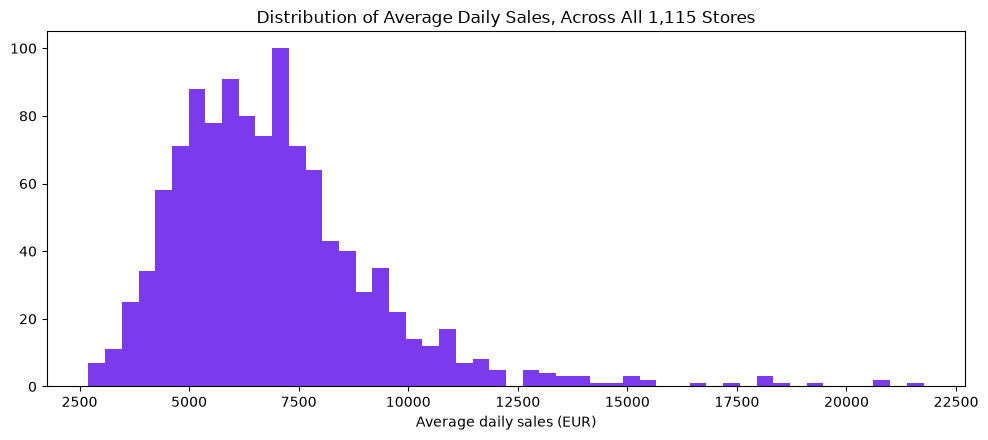

Top store average: 21,757 | Bottom store average: 2,704 | Median: 6,590


In [9]:
store_avg = sales_open.groupby('Store')['Sales'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(store_avg, bins=50, color='#7c3aed')
ax.set_title('Distribution of Average Daily Sales, Across All 1,115 Stores')
ax.set_xlabel('Average daily sales (EUR)')
plt.tight_layout()
plt.show()

print(f'Top store average: {store_avg.iloc[0]:,.0f} | Bottom store average: {store_avg.iloc[-1]:,.0f} '
      f'| Median: {store_avg.median():,.0f}')

## Key findings

- **December sales run measurably above the yearly average**, the clear seasonal peak, consistent with a general-goods retailer.
- **Promotions have a real, sizeable effect**: days with an active promo average ~39% higher sales than days without one - the strongest single lever identified here.
- **Store type 'b' stores substantially outsell the other types** on average, despite being a small minority of stores - worth investigating what's structurally different about that group rather than assuming it's noise.
- **Distance to the nearest competitor has essentially no correlation with sales** (r ≈ -0.036) - proximity to competition is not, on its own, a meaningful driver in this data.
- **Store-level performance varies widely** even after accounting for type and promo activity - a meaningful share of the variance in daily sales is store-specific, not explained by the categorical features alone.
- The Sunday day-of-week figure is **not reliable** - it's based on a tiny fraction of the store-days every other day of the week has, since most stores are closed on Sundays.

## Next steps

This notebook covers exploratory analysis. A natural follow-up on this dataset is an actual sales forecasting model (the original Kaggle competition's task) - likely gradient boosting on the engineered features here (day of week, promo, store type, holidays) plus the per-store variability identified in Section 8, which a simple average-based model wouldn't capture.